## In this notebook we  -

#### 1. Create dummy or indicator features for categorical variables
#### 2. Standardize the magnitude of numeric features using a scaler
#### 3. Split your data into testing and training datasets



In our previous Step of EDA computation, we evaluated HBM theory through some selected feature variables and found that there are some good predictors of our target variable. However, in our analysis, we explicitly selected some variables by definition and this is not a comprehensive and complete list of variables which could have been in each of the categories of HBM model.

Here we try to engineer our existing features i.e make most of all of them such that a model can utilize it and then we categorize the most important ones according to HBM theory

### 1. Load data from last step of EDA

In [144]:
import pandas as pd
import numpy as np


In [145]:
import pickle

# Replace '002-eda_final.pkl' with the actual filename if different
with open('../data/processed/002-eda_final.pkl', 'rb') as f:
    df = pickle.load(f)

df.head() # Display the first few rows of the DataFrame to verify successful loading


,_STATE,IDATE,IMONTH,DISPCODE,GENHLTH,PHYSHLTH,MENTHLTH,HLTHPLN1,PERSDOC2,MEDCOST,...,_INCOMG,_RFSMOK3,DRNKANY5,DROCDY3_,_RFBING5,_TOTINDA,_RFSEAT3,YEAR,DIABETES,_AGE65YR
0,1,2015-01-29,1.0,1200,5,15,18,1,1,2,...,2,0,2,5.397605e-79,1,2,1,2015,2,1
1,1,2015-01-20,1.0,1100,3,0,0,2,1,1,...,1,1,2,5.397605e-79,1,1,2,2015,2,1
3,1,2015-01-14,1.0,1100,5,30,30,1,2,1,...,5,0,2,5.397605e-79,1,2,1,2015,2,1
4,1,2015-01-14,1.0,1100,5,20,0,1,1,2,...,9,0,2,5.397605e-79,1,2,1,2015,2,1
5,1,2015-01-14,1.0,1100,2,0,0,1,1,2,...,4,0,2,5.397605e-79,1,1,1,2015,2,2


In [146]:
df.describe()  # Display summary statistics of the DataFrame

,IDATE,IMONTH,PHYSHLTH,MENTHLTH,CHILDREN,WEIGHT2,HEIGHT3
count,2179085,2.179085e+06,2179085.0,2179085.0,2179085.0,2.179085e+06,2.179085e+06
mean,2013-06-04 14:38:39.508967936,6.489801e+00,4.279142,3.383234,0.51711,8.076938e+01,1.693912e+00
min,2011-01-02 00:00:00,1.000000e+00,0.0,0.0,0.0,0.000000e+00,7.366000e-01
25%,2012-02-29 00:00:00,3.000000e+00,0.0,0.0,0.0,6.577200e+01,1.625600e+00
50%,2013-05-23 00:00:00,6.000000e+00,0.0,0.0,0.0,7.801920e+01,1.676400e+00
75%,2014-08-20 00:00:00,9.000000e+00,3.0,2.0,1.0,9.072000e+01,1.778000e+00
max,2016-03-08 00:00:00,1.200000e+01,30.0,30.0,5.0,3.356640e+02,6.050000e+00
std,NaN,3.413122e+00,8.786492,7.687738,0.999112,2.103886e+01,1.047857e-01


### 2. One-hot encode categorical columns

In [147]:
cat_cols = df.select_dtypes(include=['category', 'object']).columns.tolist()
print(f"Categorical columns: {cat_cols}")


Categorical columns: ['_STATE', 'DISPCODE', 'GENHLTH', 'HLTHPLN1', 'PERSDOC2', 'MEDCOST', 'CHECKUP1', 'CVDINFR4', 'CVDCRHD4', 'CVDSTRK3', 'ASTHMA3', 'CHCSCNCR', 'CHCOCNCR', 'CHCCOPD1', 'HAVARTH3', 'ADDEPEV2', 'CHCKIDNY', 'DIABETE3', 'SEX', 'MARITAL', 'RENTHOM1', 'VETERAN3', 'QLACTLM2', 'USEEQUIP', 'USENOW3', 'EXERANY2', 'PNEUVAC3', 'HIVTST6', 'QSTVER', '_RFHLTH', '_HCVU651', '_LTASTH1', '_CASTHM1', '_ASTHMS1', '_DRDXAR1', '_RFBMI5', '_CHLDCNT', '_EDUCAG', '_INCOMG', '_RFSMOK3', 'DRNKANY5', 'DROCDY3_', '_RFBING5', '_TOTINDA', '_RFSEAT3', 'YEAR', 'DIABETES', '_AGE65YR']


In [148]:
#drop the target column from the list of categorical columns
cat_cols = [col for col in cat_cols if col != '_RFSMOK3']
print(f"Final Categorical cols: {cat_cols}")

Final Categorical cols: ['_STATE', 'DISPCODE', 'GENHLTH', 'HLTHPLN1', 'PERSDOC2', 'MEDCOST', 'CHECKUP1', 'CVDINFR4', 'CVDCRHD4', 'CVDSTRK3', 'ASTHMA3', 'CHCSCNCR', 'CHCOCNCR', 'CHCCOPD1', 'HAVARTH3', 'ADDEPEV2', 'CHCKIDNY', 'DIABETE3', 'SEX', 'MARITAL', 'RENTHOM1', 'VETERAN3', 'QLACTLM2', 'USEEQUIP', 'USENOW3', 'EXERANY2', 'PNEUVAC3', 'HIVTST6', 'QSTVER', '_RFHLTH', '_HCVU651', '_LTASTH1', '_CASTHM1', '_ASTHMS1', '_DRDXAR1', '_RFBMI5', '_CHLDCNT', '_EDUCAG', '_INCOMG', 'DRNKANY5', 'DROCDY3_', '_RFBING5', '_TOTINDA', '_RFSEAT3', 'YEAR', 'DIABETES', '_AGE65YR']


In [149]:
df.columns  # Display the columns of the DataFrame to see the new features created by one-hot encoding

Index(['_STATE', 'IDATE', 'IMONTH', 'DISPCODE', 'GENHLTH', 'PHYSHLTH',
       'MENTHLTH', 'HLTHPLN1', 'PERSDOC2', 'MEDCOST', 'CHECKUP1', 'CVDINFR4',
       'CVDCRHD4', 'CVDSTRK3', 'ASTHMA3', 'CHCSCNCR', 'CHCOCNCR', 'CHCCOPD1',
       'HAVARTH3', 'ADDEPEV2', 'CHCKIDNY', 'DIABETE3', 'SEX', 'MARITAL',
       'RENTHOM1', 'VETERAN3', 'CHILDREN', 'WEIGHT2', 'HEIGHT3', 'QLACTLM2',
       'USEEQUIP', 'USENOW3', 'EXERANY2', 'PNEUVAC3', 'HIVTST6', 'QSTVER',
       '_RFHLTH', '_HCVU651', '_LTASTH1', '_CASTHM1', '_ASTHMS1', '_DRDXAR1',
       '_RFBMI5', '_CHLDCNT', '_EDUCAG', '_INCOMG', '_RFSMOK3', 'DRNKANY5',
       'DROCDY3_', '_RFBING5', '_TOTINDA', '_RFSEAT3', 'YEAR', 'DIABETES',
       '_AGE65YR'],
      dtype='object')

In [150]:
df_encoded = df.copy()  # Create a copy of the DataFrame to avoid modifying the original

In [151]:
#one-hot encode categorical columns
df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=True)

In [152]:
df_encoded.shape  # Display the shape of the DataFrame to see how many features we have after encoding

(2179085, 211)

### 3. Standardize numerical columns

In [153]:
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print(f"Numerical columns: {num_cols}")

Numerical columns: ['IMONTH', 'PHYSHLTH', 'MENTHLTH', 'CHILDREN', 'WEIGHT2', 'HEIGHT3']


From a quick glance, we notice tha _STATE and IMONTH are not numeric but rather categorical variables. We don't want to standardize these

In [154]:
#lets drop these from the list of numerical columns
num_cols = [col for col in num_cols if col not in ['_STATE', 'IMONTH']]
print(f"Final Numerical cols: {num_cols}")

Final Numerical cols: ['PHYSHLTH', 'MENTHLTH', 'CHILDREN', 'WEIGHT2', 'HEIGHT3']


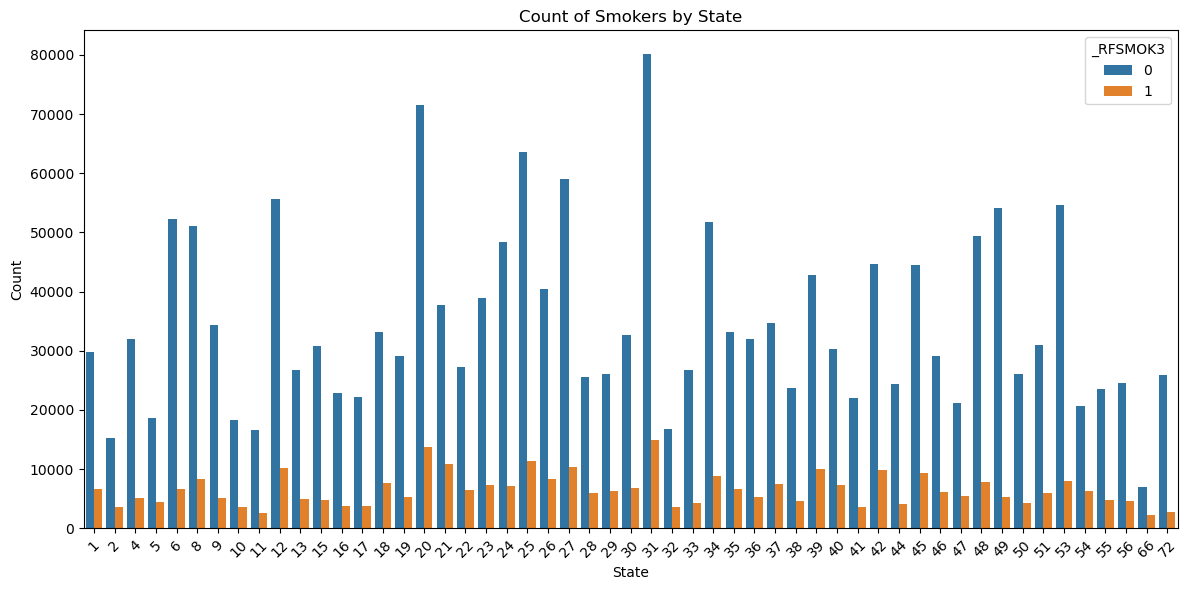

In [155]:
#plot relationship between _STATE and _RFSMOK3

import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='_STATE', hue='_RFSMOK3')
plt.title('Count of Smokers by State')
plt.xlabel('State')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.legend(title='_RFSMOK3', loc='upper right')
plt.tight_layout()
plt.show()  

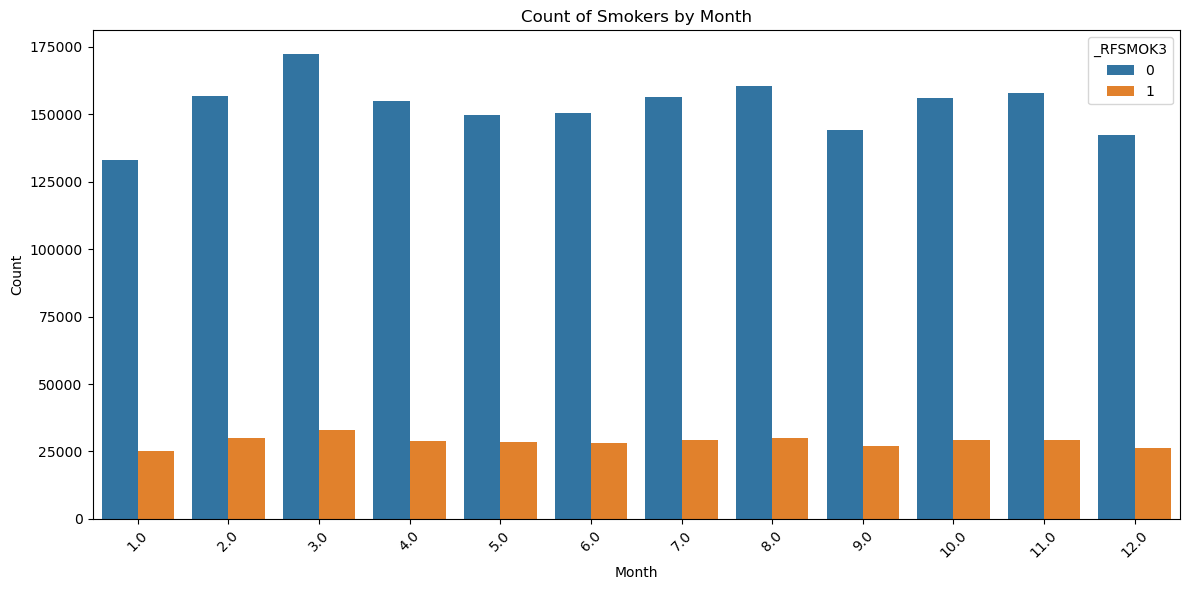

In [156]:
#plot relationship between month and _RFSMOK3
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='IMONTH', hue='_RFSMOK3')
plt.title('Count of Smokers by Month')
plt.xlabel('Month')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.legend(title='_RFSMOK3', loc='upper right')
plt.tight_layout()
plt.show()

We don't notice any particular trend between these two variable with _RFSMOK3 so we can drop these

In [157]:
#Standardize numerical columns
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df_encoded[num_cols] = scaler.fit_transform(df_encoded[num_cols])
# Save the processed DataFrame to a new pickle file
output_file = '../data/processed/003-feature-engineered.pkl'
with open(output_file, 'wb') as f:
    pickle.dump(df_encoded, f)
print(f"Processed DataFrame saved to {output_file}")

Processed DataFrame saved to ../data/processed/003-feature-engineered.pkl


### 4. Split the dataset into train and test set

##### a. Split with One-hot encoding and standardized numeric columns

In [158]:
from sklearn.model_selection import train_test_split

# Example: Let's assume '_RFSMOK3_1' is the target variable for classification
target_col = '_RFSMOK3'
X_encoded = df_encoded.drop(columns=[target_col])
y_encoded = df_encoded[target_col]

X_train_encoded, X_test_encoded, y_train_encoded, y_test_encoded = train_test_split(X_encoded, y_encoded, test_size=0.2, random_state=42, stratify=y)
print(f"Train shape: {X_train_encoded.shape}, Test shape: {X_test_encoded.shape}")

Train shape: (1743268, 210), Test shape: (435817, 210)


##### b. Split orginal dataset without One-hot encoding or standardization

In [159]:
from sklearn.model_selection import train_test_split

# Example: Let's assume '_RFSMOK3_1' is the target variable for classification
target_col = '_RFSMOK3'
X = df.drop(columns=[target_col])
y = df_encoded[target_col]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")

Train shape: (1743268, 54), Test shape: (435817, 54)


### 5. Target Encode Features with High-cardinality

#### a. Original Data

In [160]:
def frequency_encode(train_series, test_series, normalize=False):
    freq = train_series.value_counts(normalize=normalize)
    train_encoded = train_series.map(freq)
    test_encoded = test_series.map(freq)  # Unseen categories → 0
    return train_encoded, test_encoded

# Frequency encode _STATE
X_train['_STATE_FE'], X_test['_STATE_FE'] = frequency_encode(
    X_train['_STATE'],
    X_test['_STATE'],
    normalize=True  # Set to False for raw counts
)

# Optionally drop original
X_train.drop('_STATE', axis=1, inplace=True)
X_test.drop('_STATE', axis=1, inplace=True)

#convert X_train['_STATE_FE'] to int
X_train['_STATE_FE'] = X_train['_STATE_FE'].astype(int)
#convert X_test['_STATE_FE'] to int
X_test['_STATE_FE'] = X_test['_STATE_FE'].astype(int)


In [161]:
X_train['_STATE_FE'].astype(int)# Display the first few rows of the frequency-encoded series to verify successful encoding

1267517    0
522008     0
686319     0
9157       0
297012     0
          ..
1195163    0
2124859    0
1147024    0
1109419    0
1629713    0
Name: _STATE_FE, Length: 1743268, dtype: int64

### 5. Save the test and train sets into pickle files

#### a. Save encoded X_train/X_test

In [162]:
import os

# Ensure the directory exists
os.makedirs('../data/modeling/', exist_ok=True)

# Save the splits
with open('../data/modeling/data_splits_encoded.pkl', 'wb') as f:
    pickle.dump({
        'X_train': X_train_encoded,
        'X_test': X_test_encoded, 
        'y_train': y_train_encoded,
        'y_test': y_test_encoded
    }, f)

#### b. Save original X_train/X_test

In [163]:
# Save the splits
with open('../data/modeling/data_splits.pkl', 'wb') as f:
    pickle.dump({
        'X_train': X_train,
        'X_test': X_test, 
        'y_train': y_train,
        'y_test': y_test
    }, f)

## Lets take a look at our datasets one last time

In [164]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2179085 entries, 0 to 2380046
Data columns (total 55 columns):
 #   Column    Dtype         
---  ------    -----         
 0   _STATE    category      
 1   IDATE     datetime64[ns]
 2   IMONTH    float64       
 3   DISPCODE  category      
 4   GENHLTH   category      
 5   PHYSHLTH  Int64         
 6   MENTHLTH  Int64         
 7   HLTHPLN1  category      
 8   PERSDOC2  category      
 9   MEDCOST   category      
 10  CHECKUP1  category      
 11  CVDINFR4  category      
 12  CVDCRHD4  category      
 13  CVDSTRK3  category      
 14  ASTHMA3   category      
 15  CHCSCNCR  category      
 16  CHCOCNCR  category      
 17  CHCCOPD1  category      
 18  HAVARTH3  category      
 19  ADDEPEV2  category      
 20  CHCKIDNY  category      
 21  DIABETE3  category      
 22  SEX       category      
 23  MARITAL   category      
 24  RENTHOM1  category      
 25  VETERAN3  category      
 26  CHILDREN  Int64         
 27  WEIGHT2   float64

In [165]:
X_train.info()  # Display the first few rows of the training set to verify successful encoding

<class 'pandas.core.frame.DataFrame'>
Index: 1743268 entries, 1267517 to 1629713
Data columns (total 54 columns):
 #   Column     Dtype         
---  ------     -----         
 0   IDATE      datetime64[ns]
 1   IMONTH     float64       
 2   DISPCODE   category      
 3   GENHLTH    category      
 4   PHYSHLTH   Int64         
 5   MENTHLTH   Int64         
 6   HLTHPLN1   category      
 7   PERSDOC2   category      
 8   MEDCOST    category      
 9   CHECKUP1   category      
 10  CVDINFR4   category      
 11  CVDCRHD4   category      
 12  CVDSTRK3   category      
 13  ASTHMA3    category      
 14  CHCSCNCR   category      
 15  CHCOCNCR   category      
 16  CHCCOPD1   category      
 17  HAVARTH3   category      
 18  ADDEPEV2   category      
 19  CHCKIDNY   category      
 20  DIABETE3   category      
 21  SEX        category      
 22  MARITAL    category      
 23  RENTHOM1   category      
 24  VETERAN3   category      
 25  CHILDREN   Int64         
 26  WEIGHT2    fl